# Variance Reduction via Importance Sampling (Girsanov's Theorem)

## Problem

Price a deep out-of-the-money European call option under Black-Scholes,

```
dS = r S dt + sigma S dW,   S_T = S_0 exp((r - sigma^2/2) T + sigma sqrt(T) Z),  Z ~ N(0,1)
```

with a strike far above the spot (`K >> S_0`), so that only a small fraction of standard Monte
Carlo paths finish in-the-money. Standard Monte Carlo wastes almost all of its samples on paths
with zero payoff, giving a high relative variance for a fixed sample size. Importance sampling,
using a drift shift justified by Girsanov's theorem, concentrates the simulated paths where the
payoff is actually nonzero and corrects for the resulting bias with a likelihood-ratio (Radon-
Nikodym derivative) weight, reducing variance substantially for the same sample size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S0 = 100.0
K = 160.0     # deep out-of-the-money strike
r = 0.03
sigma = 0.20
T = 1.0


def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


true_price = bs_call_price(S0, K, r, sigma, T)
print(f"Closed-form Black-Scholes call price (K={K}): {true_price:.6f}")

Closed-form Black-Scholes call price (K=160.0): 0.121296


## Method

Under the risk-neutral measure `P`, `Z ~ N(0,1)` and the discounted payoff is
`f(Z) = e^{-rT} max(S_0 e^{(r-sigma^2/2)T + sigma sqrt(T) Z} - K, 0)`. The option price is
`E_P[f(Z)]`.

**Girsanov's theorem** states that shifting the driving Brownian motion by a constant drift
`theta` — i.e. sampling `Z' = Z + theta` under a new measure `Q` — changes the density of `Z`
under `Q` relative to `P` by the likelihood ratio (Radon-Nikodym derivative)

```
dP/dQ (z) = exp(-theta z + theta^2 / 2)
```

so that `E_P[f(Z)] = E_Q[f(Z) * dP/dQ(Z)]`, where under `Q`, `Z` is sampled as `Z = Z' - theta`
with `Z' ~ N(0,1)`. Equivalently: draw standard normals, shift them by `theta`, evaluate the
payoff at the shifted value, and reweight each sample by the likelihood ratio to keep the
estimator unbiased.

Choosing `theta` to shift the distribution so that its mean lands near the point that makes the
option just at-the-money (`S_T = K`) concentrates samples in the region where the payoff is
nonzero. Solving `S_0 exp((r - sigma^2/2)T + sigma sqrt(T) theta) = K` for `theta` gives the
shift used below:

```
theta* = ( ln(K/S_0) - (r - sigma^2/2) T ) / (sigma sqrt(T))
```

This is the same shift that would make `Z = theta*` the peak of the (unnormalized) shifted
density near the payoff's kink — a standard heuristic (mean-shift / exponential tilting) for
importance sampling in rare-event tail estimation.

In [2]:
theta_star = (np.log(K / S0) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
print(f"Girsanov drift shift theta* = {theta_star:.4f}")


def payoff_from_z(z):
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    return np.exp(-r * T) * np.maximum(ST - K, 0.0)


def standard_mc(n, rng):
    z = rng.standard_normal(n)
    p = payoff_from_z(z)
    return p.mean(), p.var(ddof=1)


def importance_sampling_mc(n, theta, rng):
    z_shifted = rng.standard_normal(n) + theta
    likelihood_ratio = np.exp(-theta * z_shifted + 0.5 * theta**2)
    weighted_payoff = payoff_from_z(z_shifted) * likelihood_ratio
    return weighted_payoff.mean(), weighted_payoff.var(ddof=1)


rng = np.random.default_rng(2024)
n = 100_000

std_mean, std_var = standard_mc(n, rng)
is_mean, is_var = importance_sampling_mc(n, theta_star, rng)

print(f"Standard MC:          price={std_mean:.6f}  sample variance={std_var:.6e}")
print(f"Importance sampling:   price={is_mean:.6f}  sample variance={is_var:.6e}")
print(f"Variance reduction factor: {std_var / is_var:.1f}x")

Girsanov drift shift theta* = 2.3000
Standard MC:          price=0.117085  sample variance=2.465769e+00
Importance sampling:   price=0.120698  sample variance=2.048368e-02
Variance reduction factor: 120.4x


## Variance reduction across sample sizes and fraction of in-the-money paths

To see the effect isolated from any single random draw, the comparison above is repeated across
independent trials at a fixed `n`, and the fraction of paths landing in-the-money is reported for
both schemes — this is the direct, intuitive reason importance sampling helps: far more of the
importance-sampled paths actually contribute a nonzero payoff.

In [3]:
def itm_fraction_standard(n, rng):
    z = rng.standard_normal(n)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    return (ST > K).mean()


def itm_fraction_is(n, theta, rng):
    z = rng.standard_normal(n) + theta
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    return (ST > K).mean()


rng = np.random.default_rng(7)
n_trials = 200
n_per_trial = 20_000

std_estimates = np.empty(n_trials)
is_estimates = np.empty(n_trials)
for i in range(n_trials):
    std_estimates[i], _ = standard_mc(n_per_trial, rng)
    is_estimates[i], _ = importance_sampling_mc(n_per_trial, theta_star, rng)

std_frac = itm_fraction_standard(200_000, rng)
is_frac = itm_fraction_is(200_000, theta_star, rng)

print(f"Fraction in-the-money, standard sampling:      {std_frac:.4%}")
print(f"Fraction in-the-money, importance sampling:    {is_frac:.4%}")
print()
print(f"Across {n_trials} independent trials of n={n_per_trial}:")
print(f"  Standard MC:          mean={std_estimates.mean():.6f}  std={std_estimates.std(ddof=1):.6e}")
print(f"  Importance sampling:  mean={is_estimates.mean():.6f}  std={is_estimates.std(ddof=1):.6e}")
print(f"  Empirical variance reduction factor: {(std_estimates.std(ddof=1) / is_estimates.std(ddof=1))**2:.1f}x")
print(f"  Closed-form reference: {true_price:.6f}")

Fraction in-the-money, standard sampling:      1.0595%
Fraction in-the-money, importance sampling:    50.1500%

Across 200 independent trials of n=20000:
  Standard MC:          mean=0.120214  std=1.133049e-02
  Importance sampling:  mean=0.121292  std=9.726922e-04
  Empirical variance reduction factor: 135.7x
  Closed-form reference: 0.121296


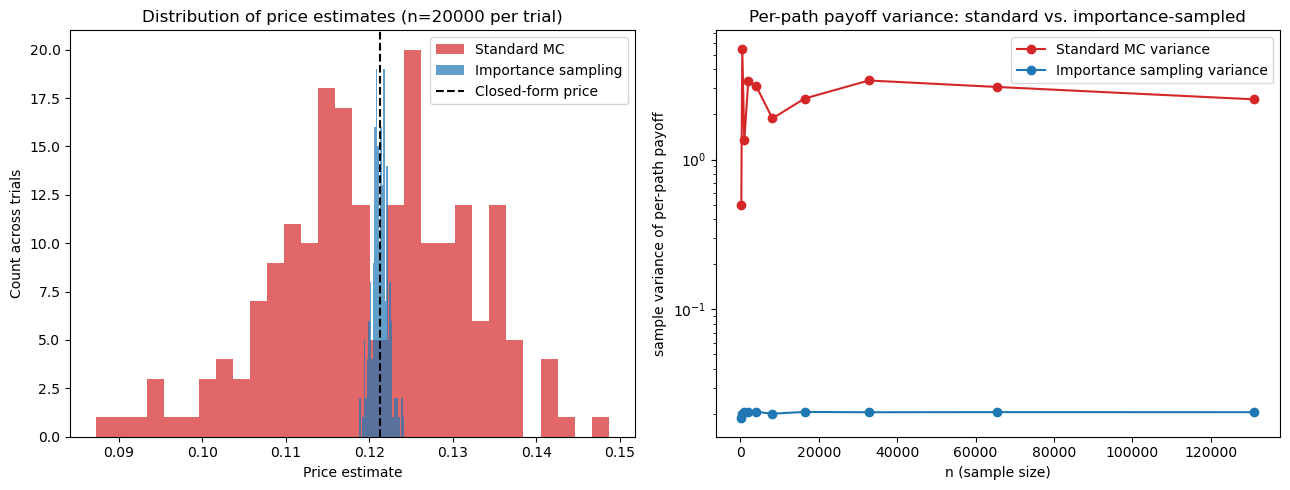

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(std_estimates, bins=30, alpha=0.7, label="Standard MC", color="tab:red")
axes[0].hist(is_estimates, bins=30, alpha=0.7, label="Importance sampling", color="tab:blue")
axes[0].axvline(true_price, color="black", linestyle="--", label="Closed-form price")
axes[0].set_xlabel("Price estimate")
axes[0].set_ylabel("Count across trials")
axes[0].set_title(f"Distribution of price estimates (n={n_per_trial} per trial)")
axes[0].legend()

ns = np.array([2**k for k in range(8, 18)])
std_vars = []
is_vars = []
rng = np.random.default_rng(55)
for nn in ns:
    _, v_std = standard_mc(int(nn), rng)
    _, v_is = importance_sampling_mc(int(nn), theta_star, rng)
    std_vars.append(v_std)
    is_vars.append(v_is)

axes[1].semilogy(ns, std_vars, "o-", label="Standard MC variance", color="tab:red")
axes[1].semilogy(ns, is_vars, "o-", label="Importance sampling variance", color="tab:blue")
axes[1].set_xlabel("n (sample size)")
axes[1].set_ylabel("sample variance of per-path payoff")
axes[1].set_title("Per-path payoff variance: standard vs. importance-sampled")
axes[1].legend()

plt.tight_layout()
plt.savefig("importance_sampling_variance_reduction.png", dpi=120, bbox_inches="tight")
plt.show()